---
## 0. Setup

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
import os

os.environ.setdefault("CHUNK_TOKEN_TARGET", "1024")
os.environ.setdefault("FIGURE_AREA_THRESHOLD", "0.01")
os.environ.setdefault("REPORT_DIR", "reports")


'reports'

In [4]:
import _json
from pathlib import Path

import pandas as pd

from rag import chunking, clients, config, docling_io, tables
from rag import index as index_module
from rag import inspect as inspection
from rag import sync as sync_module

SOURCE_PDF = Path("pdfs/AI-Enablers-Adopters-research-report.pdf")

BUCKET = None

DOC_ID = config.slugify(SOURCE_PDF.stem)

print(f"document    : {DOC_ID}")
print(f"embedding   : {config.EMBED_MODEL} ({clients.EMBED_DIMS}d)")
print(f"chunk size  : {config.CHUNK_TOKENS} tokens")
print(f"vision      : {config.VISION_MODEL}")
print(f"report      : {config.REPORT_DIR.resolve()}")

document    : ai-enablers-adopters-research-report
embedding   : text-embedding-3-small (1536d)
chunk size  : 1024 tokens
vision      : gpt-4o-mini
report      : C:\Users\yogav\PycharmProjects\langchain-agents\05-rag\reports


In [5]:
doc = docling_io.parse_pdf(SOURCE_PDF)

C:\Users\yogav\PycharmProjects\langchain-agents\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  enrichments ON : do_code_enrichment, do_formula_enrichment, do_ocr, do_picture_classification, generate_picture_images, generate_table_images
  enrichments OFF: do_chart_extraction, do_picture_description, enable_remote_services
  (do_picture_description and enable_remote_services are off on purpose — describe_figures() runs after the parse, cached)
  heading hierarchy: ENABLED — SectionHeaderItem.level will be rewritten from bookmarks, then numbering, then style. This changes what a heading path means for every downstream comparison; re-check headings.py's rules and chunking.py's merge behaviour against the new output before trusting it.
  pipeline options in effect:
    do_ocr                        True
    do_table_structure            True
    do_picture_classification     True
    do_formula_enrichment         True
    do_code_enrichment            True
    generate_picture_images       True
    generate_table_images         True
    do_picture_description        False
    enab

Loading weights: 100%|██████████| 360/360 [00:00<00:00, 10588.33it/s]
[INFO] 2026-09-02 20:10:43,129 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-02 20:10:43,154 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-09-02 20:10:43,156 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.9.2/torch/PP-OCRv6/det/PP-OCRv6_det_small.pth
[INFO] 2026-09-02 20:10:44,939 [RapidOCR] download_file.py:82: Download size: 9.77MB
[INFO] 2026-09-02 20:10:46,087 [RapidOCR] download_file.py:95: Successfully saved to: C:\Users\yogav\PycharmProjects\langchain-agents\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-02 20:10:46,090 [RapidOCR] main.py:50: Using C:\Users\yogav\PycharmProjects\langchain-agents\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-02 20:10:46,546 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-02 20:10:46,546 [RapidOCR] device

2026-09-02 20:12:26,778 MatchingPostProcessor WARNING  Orphan pdf_cell 25 recovered to row=1 by nearest-row fallback (col=0, y=261.1, dist=39.2)
2026-09-02 20:12:26,780 MatchingPostProcessor WARNING  Orphan pdf_cell 26 recovered to row=1 by nearest-row fallback (col=0, y=261.1, dist=39.2)
2026-09-02 20:12:26,781 MatchingPostProcessor WARNING  Orphan pdf_cell 27 recovered to row=1 by nearest-row fallback (col=0, y=261.1, dist=39.2)
2026-09-02 20:12:26,782 MatchingPostProcessor WARNING  Orphan pdf_cell 28 recovered to row=1 by nearest-row fallback (col=0, y=261.1, dist=39.2)
2026-09-02 20:12:26,782 MatchingPostProcessor WARNING  Orphan pdf_cell 29 recovered to row=1 by nearest-row fallback (col=0, y=261.1, dist=39.2)
2026-09-02 20:12:26,782 MatchingPostProcessor WARNING  Orphan pdf_cell 63 recovered to row=4 by nearest-row fallback (col=0, y=513.1, dist=39.2)
2026-09-02 20:12:26,783 MatchingPostProcessor WARNING  Orphan pdf_cell 64 recovered to row=4 by nearest-row fallback (col=0, y=513

self_ref='#/tables/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.TABLE: 'table'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=382.8661193847656, t=708.7370758056641, r=571.6180419921875, b=408.0410461425781, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[] references=[] footnotes=[] image=ImageRef(mimetype='image/png', dpi=144, size=Size(width=377.0, height=601.0), uri=AnyUrl('')) data=TableData(table_cells=[TableCell(bbox=BoundingBox(l=384.5, t=89.37599999999998, r=470.72075, b=114.9194558189655, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), row_span=1, col_span=1, start_row_offset_idx=0, end_row_offset_idx=1, start_col_offset_idx=0, end_col_offset_idx=1, text='Edward Stanley Equity Strategist Edward.Stanley@morganstanley.com', column_header=False, row_header=False, row_section=False, fillable=False), TableCell(bbox=BoundingBox(l=527.995, t=110.205249
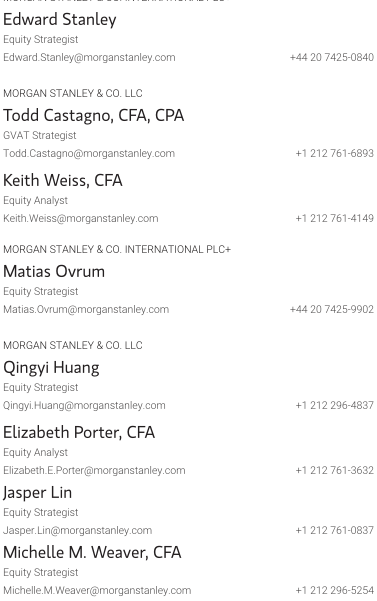
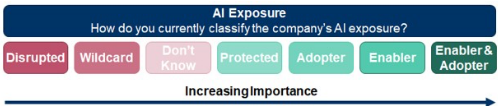
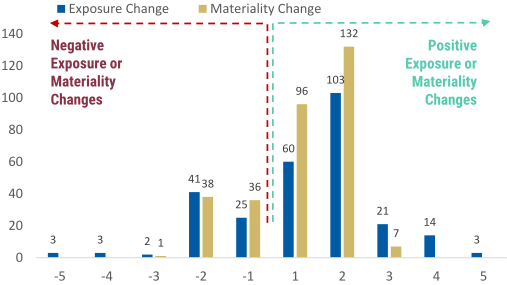

In [7]:
items = [item for item in doc.iterate_items()]
for item,level in items[13:38]:
    print(item)
    print("---------")

In [8]:
markdown = doc.export_to_markdown()
doc_date = chunking.document_date(SOURCE_PDF, markdown[:4000])

print(f"pages {len(doc.pages)}  document date: {doc_date}")

pages 7  document date: 2025
